In [4]:
import re
from itertools import combinations

with open("input.txt") as f:
    tiles = [(int(x), int(y)) for x, y in re.findall(r"(\d+),(\d+)", f.read())]
    
areas = [
    (abs(ax - bx) + 1)*(abs(ay - by) + 1)
    for (ax, ay), (bx, by) in combinations(tiles, r=2)
]

print(max(areas))

4748985168


1550760868


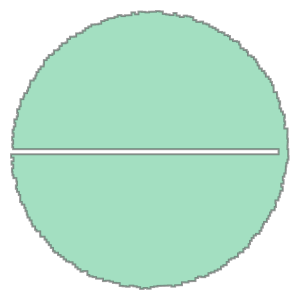

In [6]:
import re
from shapely.geometry import Polygon, box
from shapely.prepared import prep
from itertools import combinations

with open("input.txt") as f:
    tiles = [(int(x), int(y)) for x, y in re.findall(r"(\d+),(\d+)", f.read())]

red_green_raw = Polygon(tiles)
red_green = prep(red_green_raw)
rects = [
    box(min(ax, bx), min(ay, by), max(ax, bx) + 1, max(ay, by) + 1) 
    for (ax, ay), (bx, by) in combinations(tiles, r=2)
]
max_area = max(r.area for r in filter(red_green.contains, rects))

print(int(max_area))
red_green_raw